In [1]:
%matplotlib widget
import inspect
import re
def debugPrint(x):
    frame = inspect.currentframe().f_back
    s = inspect.getframeinfo(frame).code_context[0]
    r = re.search(r"\((.*)\)", s).group(1)
    print("{} [{}] = {}".format(r,type(x).__name__, x))
       
import torch
import numpy as np
import warp as wp

# Initialize Warp
wp.config.verify_autograd_array_access = False
wp.config.verbose = False
wp.init()

from sphWarpCore import radiusSearchCompactHashMap, sphOperation_warp
from sphWarpCore.enumTypes import *

import matplotlib.pyplot as plt
from demo_util import *
from warpPlot import *

Warp 1.12.0 initialized:
   CUDA Toolkit 12.9, Driver 13.2
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA RTX PRO 500 Blackwell Generation Laptop GPU" (6 GiB, sm_120, mempool enabled)
   Kernel cache:
     /home/lu26029/.cache/warp/1.12.0


In [17]:
device = torch.device('cpu')
device = torch.device('cuda')
targetNumNeighbors = 50
nx = 128
dim = 2
numParticles = nx**dim

warpOnly = False
periodic = True

kernel = KernelFunctions.Wendland2
supportMode = SupportScheme.Gather

markerSize = 8 if warpOnly else 2
gridVisualization = False 
gridResolution = 128
dx = 2.0 / nx

In [18]:
particleState, domain, adjacency, neighborhood, simulationState, measurements = prepData(nx, targetNumNeighbors, dim, device, periodic, warpOnly)
apparentVolume, crkDensity, crkState = computeCRKFactors(particleState, domain, kernel, adjacency = adjacency)

Linear Gradient (WarpSPH):  tensor([[-2.2642e+02,  6.7026e+00],
        [-8.6308e+01,  3.8346e+00],
        [-1.3988e+01,  1.1882e+00],
        ...,
        [-1.1679e+01,  3.0605e-02],
        [-9.1087e+01,  2.1500e+00],
        [-2.1525e+02,  9.7821e+00]], device='cuda:0')
Mean Absolute Error in X Gradient:  5.038508892059326
Mean Absolute Error in Y Gradient:  0.18463608622550964


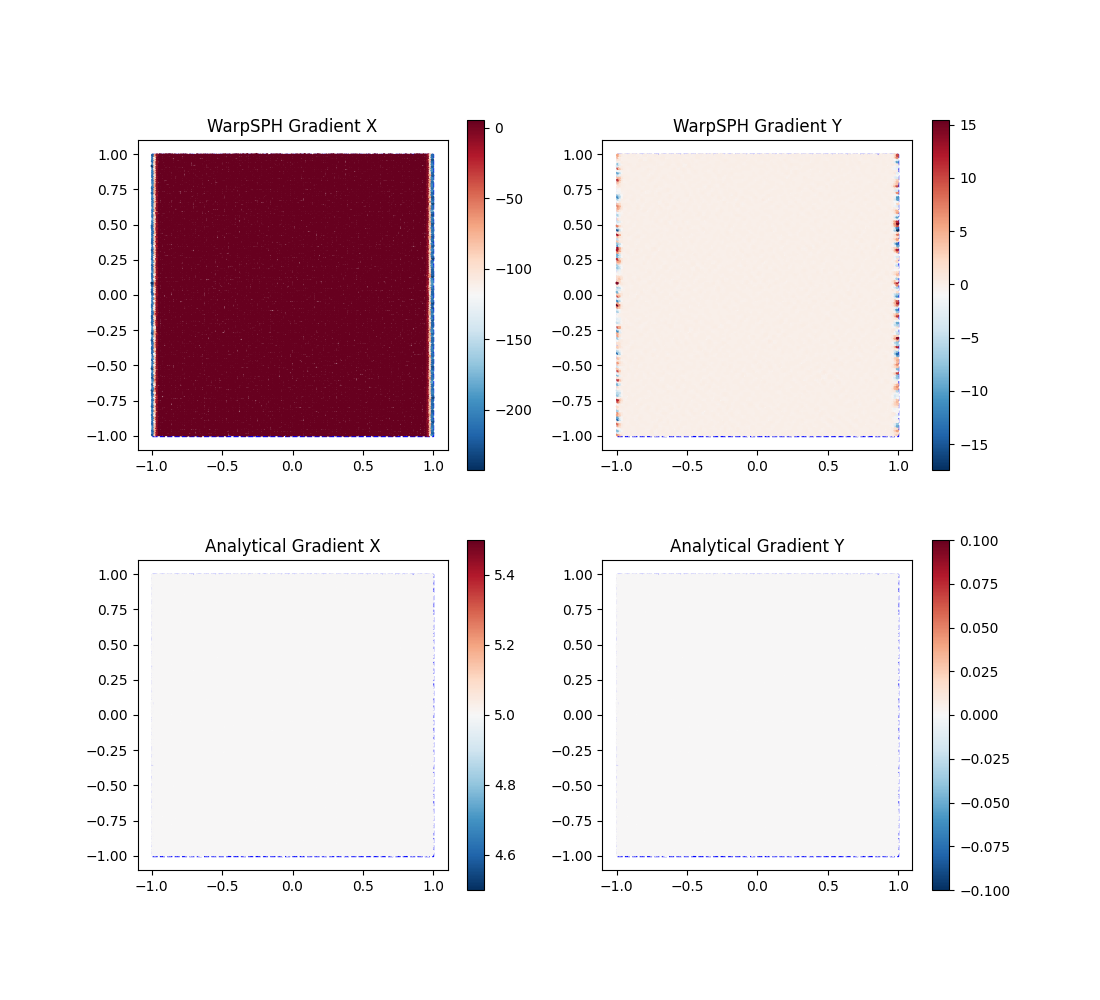

In [20]:
f_linear = particleState.positions[:,0] * 5 + 10
f_grad_x = torch.full_like(f_linear, 5.0)
f_grad_y = torch.zeros_like(f_linear)

linear_gradient_warp = warpOperation(
    queryParticles = particleState,
    queryValues = f_linear,
    operationProperties=OperationProperties(
        kernel = kernel,
        supportMode = supportMode,
        operation = WarpOperation.Gradient,
        gradientMode = GradientScheme.Difference,
    ),
    adjacency = adjacency,
    domain = domain,
)

print("Linear Gradient (WarpSPH): ", linear_gradient_warp)

mean_error_x = torch.mean(torch.abs(linear_gradient_warp[:,0] - f_grad_x))
mean_error_y = torch.mean(torch.abs(linear_gradient_warp[:,1] - f_grad_y))

print("Mean Absolute Error in X Gradient: ", mean_error_x.item())
print("Mean Absolute Error in Y Gradient: ", mean_error_y.item())

fig, axis = plt.subplots(2,2, figsize = (11,10), squeeze=False)

plotSettings = PlottingOptions(
    colorMap = ColorMap.RdBu,
    flipColorMap = True,
    showColorBar = True,
    markerSize = markerSize,
    gridVisualization = GridVisualization(
        resolution = gridResolution,
    ) if gridVisualization else None,
)

# as the visualize function accepts kwargs we can predefine common plotting settings in a PlottingOptions dataclass and then unpack it when calling the function to keep the code cleaner and more organized, especially when we have multiple visualizations that share the same settings. This way we can easily modify the common settings in one place without having to change each individual visualization call.
# For this case we explicitly extract the gradient components before calling the visualize function
visualizeParticlesNew(fig, axis[0,0], particleState, quantity = linear_gradient_warp[:,0], domain = domain, options = plotSettings, plotTitle = "WarpSPH Gradient X");
visualizeParticlesNew(fig, axis[0,1], particleState, quantity = linear_gradient_warp[:,1], domain = domain, options = plotSettings, plotTitle = "WarpSPH Gradient Y");
visualizeParticlesNew(fig, axis[1,0], particleState, quantity = f_grad_x, domain = domain, options = plotSettings, plotTitle = "Analytical Gradient X");
visualizeParticlesNew(fig, axis[1,1], particleState, quantity = f_grad_y, domain = domain, options = plotSettings, plotTitle = "Analytical Gradient Y");


os.makedirs("output", exist_ok=True)
fig.savefig("output/linearGradient_warpSPH.png", dpi=300)

In [21]:
print("Testing Linear Interpolation with WarpSPH...")
print("Input Function: f(x,y) = 5x + 10", 'Min: ', torch.min(f_linear), "Max: ", torch.max(f_linear))
linear_interp = warpOperation(
    queryParticles = particleState,
    queryValues = f_linear,
    operationProperties=OperationProperties(
        kernel = kernel,
        supportMode = supportMode,
        operation = WarpOperation.Interpolate,
        gradientMode = GradientScheme.Difference,
    ),
    adjacency = None,
    domain = domain,
)
print("Linear Interpolation (WarpSPH): ", linear_interp, "Min: ", torch.min(linear_interp), "Max: ", torch.max(linear_interp))

Testing Linear Interpolation with WarpSPH...
Input Function: f(x,y) = 5x + 10 Min:  tensor(5.0195, device='cuda:0') Max:  tensor(14.9795, device='cuda:0')
Linear Interpolation (WarpSPH):  tensor([ 8.4207,  5.8717,  5.3721,  ..., 14.9027, 14.4687, 12.0102],
       device='cuda:0') Min:  tensor(5.0651, device='cuda:0') Max:  tensor(15.2366, device='cuda:0')


In [22]:
f = torch.randn(numParticles, device=device, dtype=torch.float32)

f_smoothed = f.clone()

for _ in range(4):
    f_smoothed = warpOperation(
        queryParticles = particleState,
        queryValues = f_smoothed,
        operationProperties = OperationProperties(
            kernel = kernel,
            supportMode = supportMode,
            operation = WarpOperation.Interpolate,
        ),
        adjacency = None,
        domain = domain,
    )

gradient_warp = warpOperation(
    queryParticles = particleState,
    queryValues = f_smoothed,
    operationProperties = OperationProperties(
        kernel = kernel,
        supportMode = supportMode,
        operation = WarpOperation.Gradient,
        gradientMode = GradientScheme.Difference,
    ),
    adjacency = adjacency,
    domain = domain,
)


if not warpOnly:
    gradient_diffSPH = SPHOperation(
        simulationState,
        quantity = f_smoothed,
        kernel = KernelType.Wendland2,
        neighborhood = neighborhood[0],
        kernelValues = neighborhood[1],
        operation=Operation.Gradient,
        gradientMode=GradientMode.Difference,
        supportScheme = SupportScheme.Gather,
        correctionTerms= [],
        positiveDivergence=False
    )



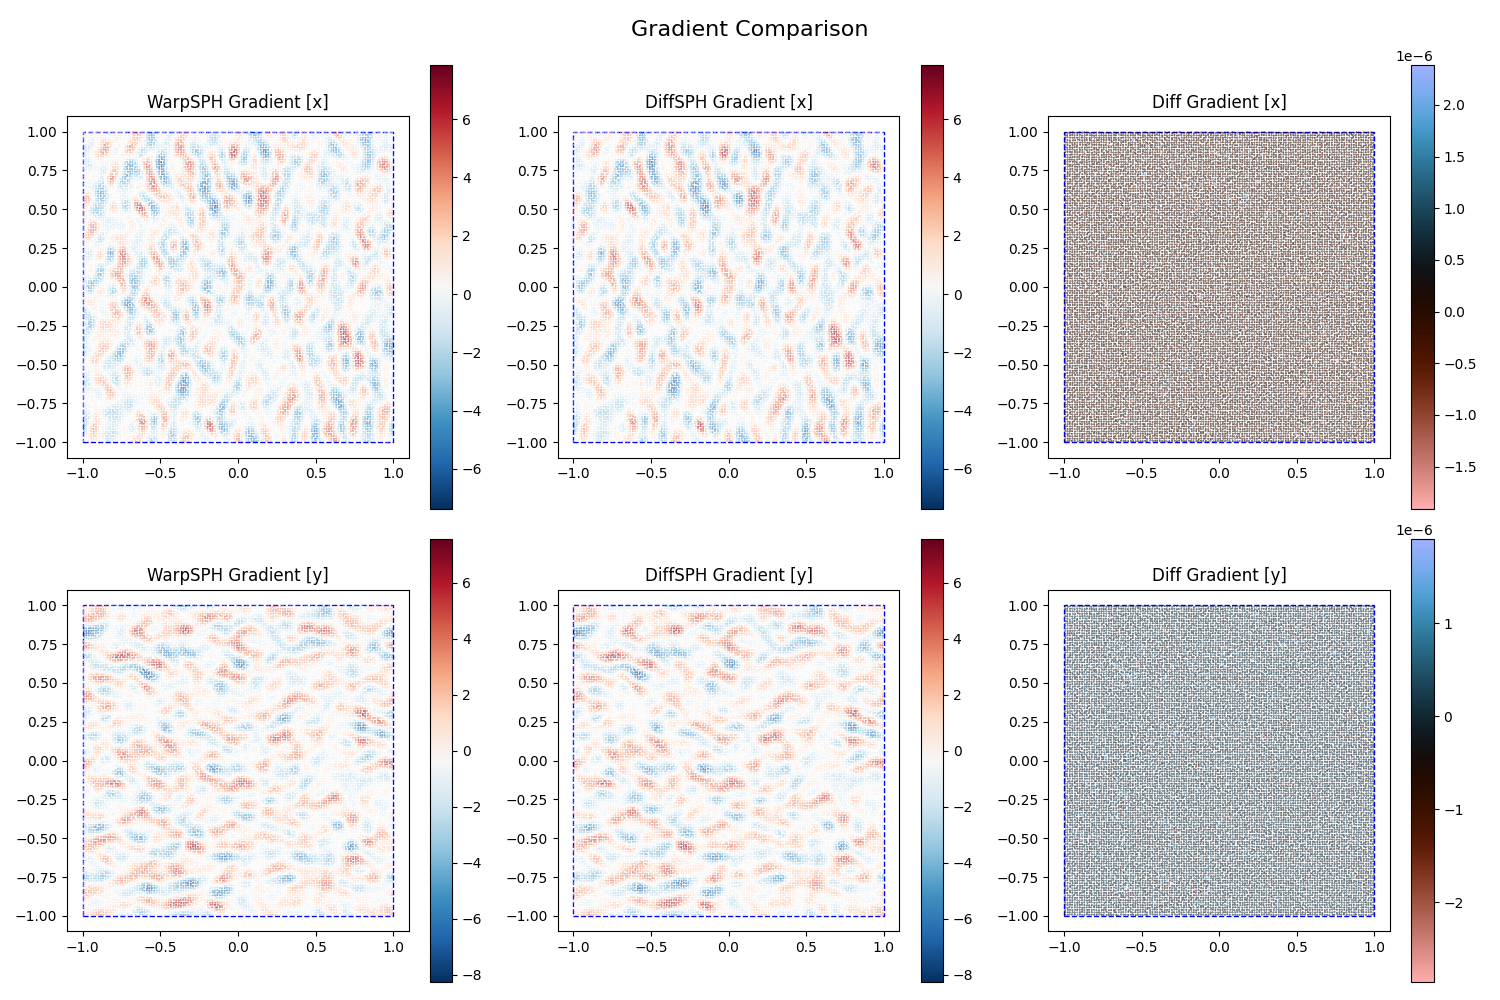

In [23]:
fig, axis = plt.subplots(2,3 if not warpOnly else 1, figsize = (15 if not warpOnly else 11,10), squeeze=False)
markerSize = 8 if warpOnly else 2
gridVisualization = False 
gridResolution = 128

plotSettings = PlottingOptions(
    colorMap = ColorMap.RdBu,
    flipColorMap = True,
    showColorBar = True,
    markerSize = 0.1,
    gridVisualization = GridVisualization(
        resolution = gridResolution,
    ) if gridVisualization else None,
)

# We can also provide the vector quantity directly and set the mapping to extract the component internally.
visualizeParticlesNew(fig, axis[0,0], particleState, quantity = gradient_warp, domain = domain, options = plotSettings, plotTitle = "WarpSPH Gradient [x]", mapping = Mapping.x);
visualizeParticlesNew(fig, axis[1,0], particleState, quantity = gradient_warp, domain = domain, options = plotSettings, plotTitle = "WarpSPH Gradient [y]", mapping = Mapping.y);

if not warpOnly:    
    visualizeParticlesNew(fig, axis[0,1], particleState, quantity = gradient_diffSPH, domain = domain, options = plotSettings, plotTitle = "DiffSPH Gradient [x]", mapping = Mapping.x);
    visualizeParticlesNew(fig, axis[1,1], particleState, quantity = gradient_diffSPH, domain = domain, options = plotSettings, plotTitle = "DiffSPH Gradient [y]", mapping = Mapping.y);

    diff_x = gradient_warp[:,0] - gradient_diffSPH[:,0]
    diff_y = gradient_warp[:,1] - gradient_diffSPH[:,1]

    visualizeParticlesNew(fig, axis[0,2], particleState, quantity = diff_x, domain = domain, options = plotSettings, plotTitle = "Diff Gradient [x]", colorMap = ColorMap.berlin);
    visualizeParticlesNew(fig, axis[1,2], particleState, quantity = diff_y, domain = domain, options = plotSettings, plotTitle = "Diff Gradient [y]", colorMap = ColorMap.berlin);


fig.suptitle("Gradient Comparison" if not warpOnly else "WarpSPH Gradient", fontsize = 16)
fig.tight_layout()

fig.savefig("output/smoothedGradient_comparison.png", dpi=300)


In [24]:
from warpPlot import *

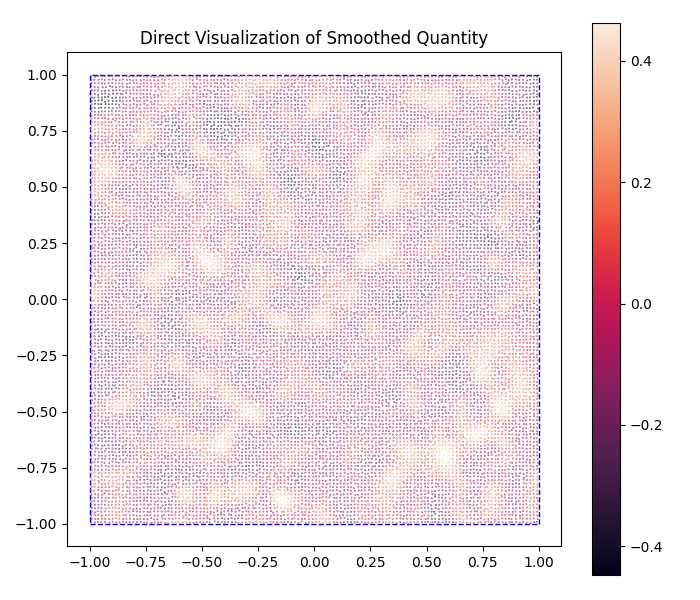

In [25]:
fig, axis = plt.subplots(1,1, figsize=(7,6), squeeze=False)

# Here we visualize the quantity directly as a scatter plot of the particle quantities
newState = visualizeParticlesNew(
    fig, axis[0,0],
    particleState = particleState,
    domain = domain,
    quantity = f_smoothed,
    options = PlottingOptions(
        colorMap = ColorMap.rocket,
        markerSize = 0.1,
        midPoint = 'median',
        plotTitle = "Direct Visualization of Smoothed Quantity",
    ),
    verbose = False,
)

fig.tight_layout()
# fig.savefig("output/smoothedQuantity_visualization.png", dpi=300)

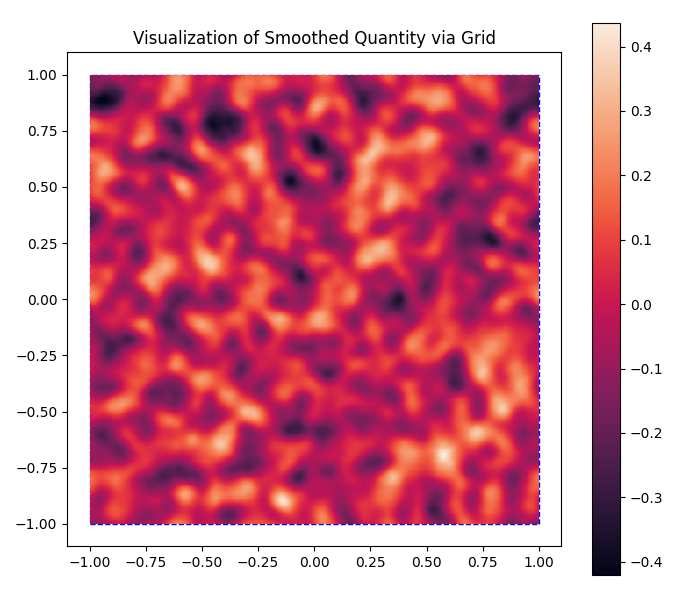

In [26]:
fig, axis = plt.subplots(1,1, figsize=(7,6), squeeze=False)

# Here we visualize the quantity directly as a scatter plot of the particle quantities
newState = visualizeParticlesNew(
    fig, axis[0,0],
    particleState = particleState,
    domain = domain,
    quantity = f_smoothed,
    options = PlottingOptions(
        colorMap = ColorMap.rocket,
        markerSize = 0.1,
        midPoint = 'median',
        plotTitle = "Visualization of Smoothed Quantity via Grid",
        gridVisualization = GridVisualization(
            resolution = 512,
        ),
    ),
    verbose = False,
)


fig.tight_layout()
fig.savefig("output/smoothedQuantity_visualization_Grid.png", dpi=300)

In [27]:
# Example of updating the plot with new data (e.g., after a simulation step)
updatePlot(
    newState,
    particles = particleState,
    domain = domain,
    quantity = -f_smoothed,
    colorMap = ColorMap.viridis,
)
fig.savefig("output/smoothedQuantity_visualization_Grid_updated.png", dpi=300)

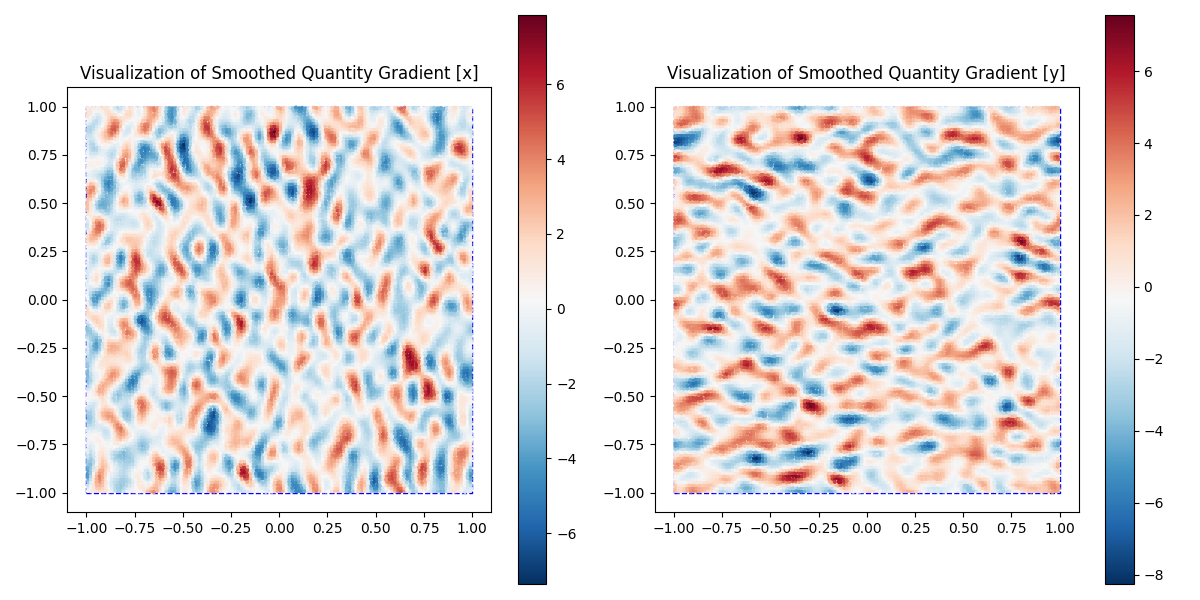

In [28]:
fig, axis = plt.subplots(1,2, figsize=(12,6), squeeze=False)

# Here we visualize the gradient of the smoothed quantity by computing the gradient within the plotting function instead of supplying it explicitly. This allows us to see how the plotting function handles the gradient computation and visualization in one step, which can be useful for debugging and understanding the behavior of the gradient field without needing to compute it separately beforehand.
newState = visualizeParticlesNew(
    fig, axis[0,0],
    particleState = particleState,
    domain = domain,
    quantity = f_smoothed,
    options = PlottingOptions(
        colorMap = ColorMap.RdBu,
        flipColorMap = True,
        markerSize = 4,
        plottingOperation = OperationProperties(
            kernel = kernel,
            operation = WarpOperation.Gradient,
            gradientMode = GradientScheme.Difference,
        ),
        mapping=Mapping.x,
        plotTitle = "Visualization of Smoothed Quantity Gradient [x]"
    ),
    verbose = False,
)

newState = visualizeParticlesNew(
    fig, axis[0,1],
    particleState = particleState,
    domain = domain,
    quantity = f_smoothed,
    options = PlottingOptions(
        colorMap = ColorMap.RdBu,
        flipColorMap = True,
        markerSize = 4,
        plottingOperation = OperationProperties(
            kernel = kernel,
            operation = WarpOperation.Gradient,
            gradientMode = GradientScheme.Difference,
        ),
        mapping=Mapping.y,
        plotTitle = "Visualization of Smoothed Quantity Gradient [y]"
    ),
    verbose = False,
)

fig.tight_layout()
fig.savefig("output/smoothedGradient_visualization.png", dpi=300)

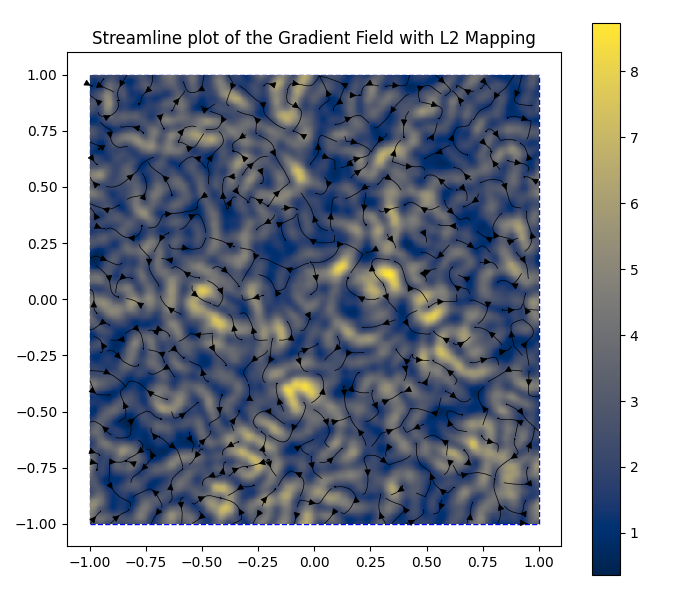

In [31]:
fig, axis = plt.subplots(1,1, figsize=(7,6), squeeze=False)

# We can also directly visualize the gradient magnitude while plotting streamlines of the gradient field before mapping to see the raw gradient field structure without the influence of the mapping operation. This can be useful for debugging and understanding the behavior of the gradient field itself.
newState = visualizeParticlesNew(
    fig, axis[0,0],
    particleState = particleState,
    domain = domain,
    quantity = gradient_warp,
    options = PlottingOptions(
        colorMap = ColorMap.cividis,
        showColorBar = True,
        markerSize = 2,
        midPoint = 'median',
        quantityScaling = PlotScaling.Linear,
        mapping = Mapping.L2,
        plottingOperation = None,
        gridVisualization = GridVisualization(
            resolution = 512,
            streamLines = True,
            streamLineOperationLocation=StreamLineLocation.BeforeMapping,
            streamLineOperation=None
        ),
        plotTitle = "Streamline plot of the Gradient Field with L2 Mapping"
    ),
    verbose = False,
)

fig.tight_layout()
fig.savefig("output/gradientStreamlines_beforeMapping.png", dpi=300)

In [20]:
updatePlot(
    newState,
    particles = particleState,
    domain = domain,
    quantity = gradient_warp,
    colorMap = ColorMap.viridis,
)
fig.savefig("output/gradientStreamlines_beforeMapping_updated.png", dpi=300)